# 02. Symmetrical components, cycle by cycle

Notebook 01 inferred the sequence content the long way round, through the
harmonics. The direct method is older and cleaner: estimate the fundamental
phasor of each phase over one cycle, then resolve the three phasors into their
symmetrical components with the inverse Fortescue transform. Repeat on a sliding
one-cycle window and the zero, positive and negative sequences become time series
that track the event.

This is where the decomposition earns its keep. A balanced supply is pure
positive sequence. Negative sequence shows up with phase-to-phase faults, zero
sequence with earth faults, so the three components read together tell you what
kind of disturbance you are looking at.

The per-cycle phasor estimate and the transform itself live in the project's
numerical kernel, which is withheld from the public release. The sliding-window
decomposition that calls it runs in `scripts/run_sequence_analysis.py` and is
read back here from `artifacts/`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from seqanalysis.plotting import plot_sequence_series, save_figure, setup_style


def project_root() -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "seqanalysis").exists():
            return parent
    return Path.cwd()


setup_style()
ROOT = project_root()
ARTIFACTS = ROOT / "artifacts"
meta = json.loads((ARTIFACTS / "meta.json").read_text())
voltage = pd.read_parquet(ARTIFACTS / "symmetrical_voltage.parquet")
current = pd.read_parquet(ARTIFACTS / "symmetrical_current.parquet")
voltage.head()

,window,time_s,phase_kind,sequence,amplitude,phase_deg,phase_offset_deg
0,0,0.000000,voltage,Z,11.585857,151.106566,209.904824
1,0,0.000000,voltage,P,8921.436520,-58.798258,0.000000
2,0,0.000000,voltage,N,166.778388,48.080405,106.878663
3,1,0.000611,voltage,Z,11.827077,162.658595,210.222677
4,1,0.000611,voltage,P,8921.800716,-47.564082,0.000000


## Voltage sequence amplitudes

Each window gives one amplitude per sequence. The positive sequence sits well
above the other two for the whole record, which confirms a working supply, but
notice that its amplitude is not constant. The disturbance modulates the balanced
component itself, not just the imbalance riding on it.

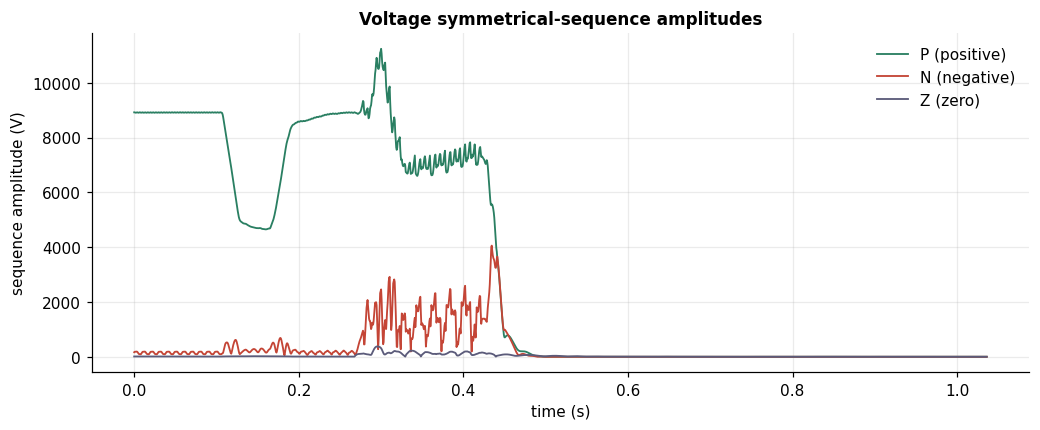

In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_sequence_series(ax, voltage, "amplitude", "sequence amplitude (V)")
ax.set_title("Voltage symmetrical-sequence amplitudes")
save_figure(fig, "voltage_sequence_amplitudes", ROOT / "reports" / "figures")
plt.show()

The negative and zero sequences are small but clearly non-zero, and they move
during the event. The ratio of negative to positive sequence is the standard
voltage-unbalance factor; its excursions here are where a protection relay would
start paying attention.

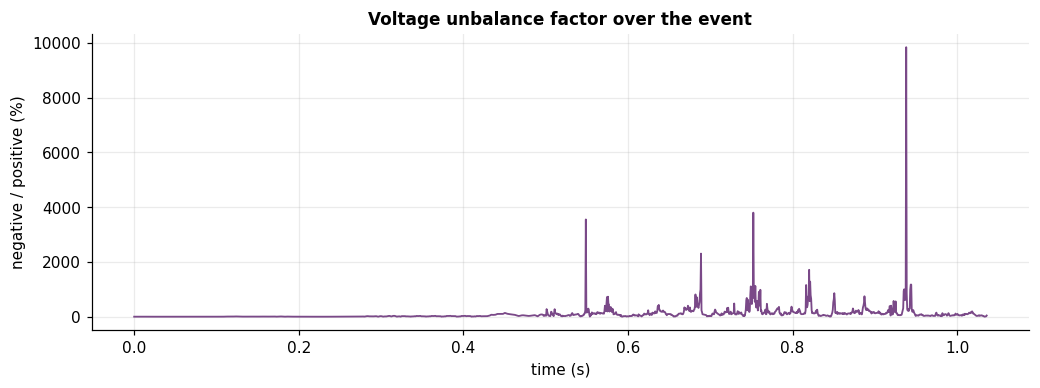

In [3]:
positive = voltage[voltage["sequence"] == "P"].set_index("window")["amplitude"]
negative = voltage[voltage["sequence"] == "N"].set_index("window")["amplitude"]
unbalance = (100.0 * negative / positive).rename("unbalance_pct")
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(
    voltage[voltage["sequence"] == "P"]["time_s"].to_numpy(),
    unbalance.to_numpy(),
    color="#7a4988",
    lw=1.2,
)
ax.set_xlabel("time (s)")
ax.set_ylabel("negative / positive (%)")
ax.set_title("Voltage unbalance factor over the event")
plt.show()

## Sequence phase offsets

Amplitudes tell you how much of each sequence is present; the phases tell you how
they sit relative to one another. Measuring each sequence phase against the
positive sequence strips out the arbitrary cycle-start reference and leaves the
offsets that actually mean something. A steady negative-sequence offset points to
a sustained asymmetry rather than a passing transient.

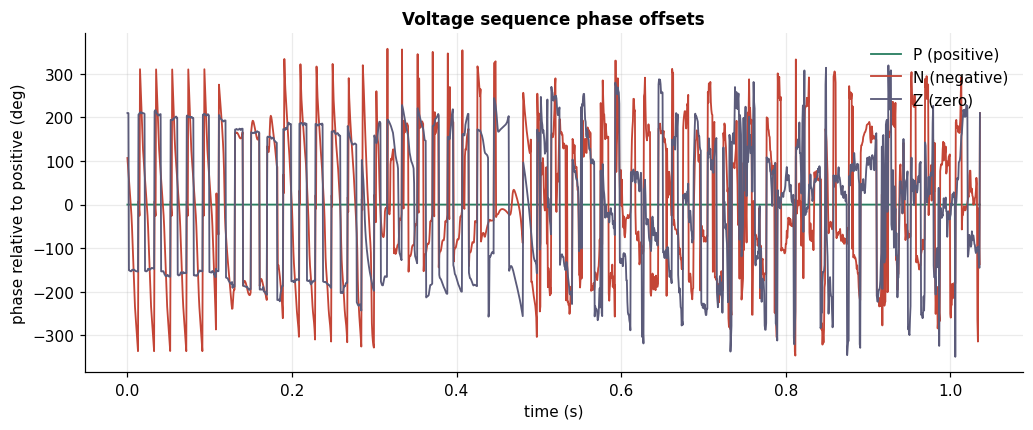

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_sequence_series(ax, voltage, "phase_offset_deg", "phase relative to positive (deg)")
ax.set_title("Voltage sequence phase offsets")
plt.show()

## Current follows

The current sequences carry the same decomposition on the load side. Comparing
the negative-sequence current against the negative-sequence voltage is the basis
of the sequence-impedance picture used in fault location, though that needs a
longer record than this one.

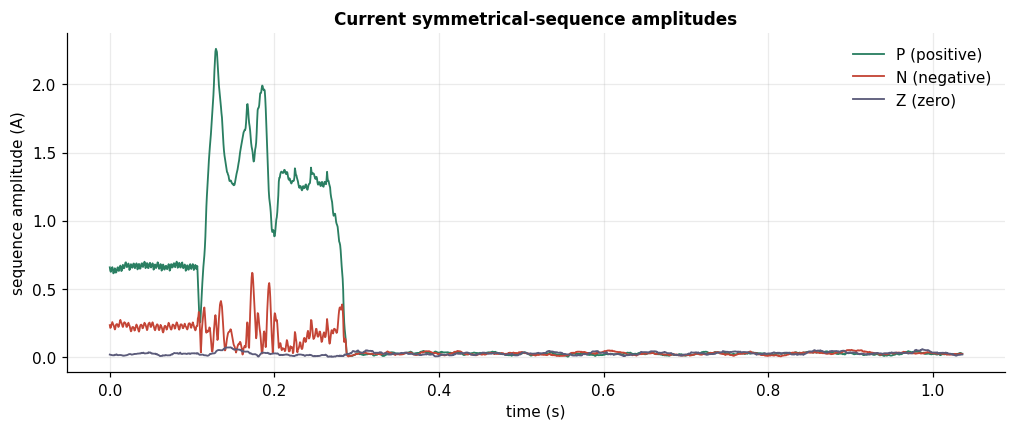

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_sequence_series(ax, current, "amplitude", "sequence amplitude (A)")
ax.set_title("Current symmetrical-sequence amplitudes")
plt.show()

## Summary

- Estimating the fundamental phasor per cycle and applying the inverse Fortescue
  transform turns one burst of telemetry into zero, positive and negative
  sequence time series.
- The supply is positive-sequence dominated throughout. The negative and zero
  sequences are small but move during the event, and their ratio to the positive
  sequence is the unbalance factor a relay would watch.
- The phase offsets relative to the positive sequence separate sustained
  asymmetry from transient excursions.
- The per-cycle phasor method is more direct and better behaved than the harmonic
  grouping in notebook 01. It is the one to build fault logic on.